In [103]:
!pip install fuzzywuzzy python-Levenshtein openai
!pip install -q transformers accelerate bitsandbytes


In [104]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
from google.colab import files

# Set today's date as per the assignment (2026-07-31)
TODAY = pd.Timestamp("2026-07-31")
NEXT_90_DAYS = TODAY + pd.Timedelta(days=90)

print(f"Looking at renewals from {TODAY} to {NEXT_90_DAYS}")

Looking at renewals from 2026-07-31 00:00:00 to 2026-10-29 00:00:00


In [105]:
# Load the structured CSVs
accounts = pd.read_csv('accounts.csv')
usage = pd.read_csv('usage_metrics.csv')
support = pd.read_csv('support_tickets.csv')
nps = pd.read_csv('nps_responses.csv')

# Convert dates
accounts['contract_end_date'] = pd.to_datetime(accounts['contract_end_date'])
support['created_date'] = pd.to_datetime(support['created_date'])
usage['month'] = pd.to_datetime(usage['month'])

print("✅ Accounts:", accounts.shape)
print("✅ Usage:", usage.shape)
print("✅ Support:", support.shape)
print("✅ NPS:", nps.shape)

✅ Accounts: (120, 8)
✅ Usage: (720, 7)
✅ Support: (271, 8)
✅ NPS: (98, 3)


In [106]:
# Filter to only accounts whose contract ends in the next 90 days
renewing_accounts = accounts[
    (accounts['contract_end_date'] >= TODAY) &
    (accounts['contract_end_date'] <= NEXT_90_DAYS)
].copy()

print(f"Total accounts: {len(accounts)}")
print(f"Accounts renewing in next 90 days: {len(renewing_accounts)}")

# Show the first few to verify
renewing_accounts[['account_id', 'account_name', 'contract_end_date']].head()

Total accounts: 120
Accounts renewing in next 90 days: 29


,account_id,account_name,contract_end_date
32,1032,Obsidian Data,2026-07-31
36,1036,Iron Bridge Capital,2026-08-15
37,1037,Crystal Clear Analytics,2026-10-20
39,1039,Redwood Health,2026-09-03
41,1041,Amber Trail Outdoors,2026-10-07


In [107]:
# --- 1. AGGREGATE SUPPORT TICKETS ---
# Count total tickets, and count high-priority (P1) open tickets
support_agg = support.groupby('account_id').agg(
    total_tickets=('ticket_id', 'count'),
    open_tickets=('status', lambda x: (x == 'Open').sum()),
    p1_tickets=('priority', lambda x: (x == 'P1').sum()),
    avg_resolution=('resolution_time_hours', lambda x: x.dropna().mean())
).reset_index()

# --- 2. AGGREGATE NPS ---
# Average NPS score per account
nps_agg = nps.groupby('account_id').agg(
    avg_nps=('score', 'mean')
).reset_index()

# --- 3. AGGREGATE USAGE (Compute latest month and trend) ---
# First, get the last month's usage per account
latest_usage = usage.sort_values('month').groupby('account_id').last().reset_index()

# Calculate usage trend (slope of API calls over 6 months) - Higher negative slope = riskier
def calculate_slope(group):
    if len(group) < 2:
        return 0
    x = np.arange(len(group))
    slope = np.polyfit(x, group['api_calls'], 1)[0]
    return slope

usage_trend = usage.groupby('account_id').apply(calculate_slope).reset_index(name='api_trend')

# Merge all usage features
usage_agg = latest_usage[['account_id', 'api_calls', 'active_users', 'sdk_version']].merge(
    usage_trend, on='account_id', how='left'
)

# --- 4. MERGE EVERYTHING into the renewing accounts list ---
df = renewing_accounts.merge(usage_agg, on='account_id', how='left')
df = df.merge(support_agg, on='account_id', how='left')
df = df.merge(nps_agg, on='account_id', how='left')

# Fill missing values (e.g., accounts with no NPS or tickets)
df.fillna({'total_tickets': 0, 'open_tickets': 0, 'p1_tickets': 0,
           'avg_resolution': 0, 'avg_nps': 7, 'api_trend': 0}, inplace=True)

print("✅ Merged DataFrame shape:", df.shape)
df[['account_name', 'contract_end_date', 'api_calls', 'total_tickets', 'avg_nps']].head(10)

✅ Merged DataFrame shape: (29, 17)


/tmp/ipykernel_548/1112131405.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  usage_trend = usage.groupby('account_id').apply(calculate_slope).reset_index(name='api_trend')


,account_name,contract_end_date,api_calls,total_tickets,avg_nps
0,Obsidian Data,2026-07-31,26373,3.0,7.0
1,Iron Bridge Capital,2026-08-15,4933,0.0,10.0
2,Crystal Clear Analytics,2026-10-20,27775,1.0,10.0
3,Redwood Health,2026-09-03,227085,0.0,10.0
4,Amber Trail Outdoors,2026-10-07,239284,3.0,2.0
5,Windmill Energy,2026-08-19,5493,3.0,7.0
6,Fossil Creek Ranch,2026-08-21,265712,2.0,7.0
7,Cerulean Aerospace,2026-09-21,95959,1.0,9.0
8,Pearl Harbor Memorial Trust,2026-10-05,28840,0.0,7.0
9,Magenta Health,2026-08-22,5293,2.0,6.0


In [108]:
# --- Cell 6: Compute Risk Score (Rule-Based) ---

# Normalize features to 0–1 scale (higher = more risk)
def normalize(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

# Usage Risk: negative trend = high risk, low API calls = high risk
df['usage_risk'] = 0.5 * normalize(-df['api_trend'].clip(lower=-1000, upper=1000)) + \
                   0.5 * normalize(1 / (df['api_calls'] + 1))

# Support Risk: more tickets, more open tickets, more P1s
df['support_risk'] = 0.4 * normalize(df['total_tickets']) + \
                     0.3 * normalize(df['open_tickets']) + \
                     0.3 * normalize(df['p1_tickets'])

# NPS Risk: lower NPS = higher risk (NPS range 0–10)
df['nps_risk'] = normalize(10 - df['avg_nps'])

# Composite risk score (weights can be adjusted)
df['risk_score'] = 0.40 * df['usage_risk'] + \
                   0.35 * df['support_risk'] + \
                   0.25 * df['nps_risk']

# Scale to 0–100
df['risk_score'] = df['risk_score'] * 100

# Assign tiers
def tier(score):
    if score >= 70:
        return 'High'
    elif score >= 40:
        return 'Medium'
    else:
        return 'Low'

df['risk_tier'] = df['risk_score'].apply(tier)

# Sort by highest risk
df_sorted = df.sort_values('risk_score', ascending=False)

# Show the top 10 at-risk accounts
print("🏆 Top 10 At-Risk Accounts (Rule-Based):")
display(df_sorted[['account_name', 'contract_end_date', 'risk_score', 'risk_tier',
                   'api_calls', 'total_tickets', 'avg_nps']].head(10))

🏆 Top 10 At-Risk Accounts (Rule-Based):


,account_name,contract_end_date,risk_score,risk_tier,api_calls,total_tickets,avg_nps
26,Stargazer Telescopes,2026-10-20,71.083860,High,4936,3.0,7.0
28,Sunstone Energy,2026-10-22,60.612887,Medium,101429,3.0,2.0
23,Oakridge Retail,2026-10-25,60.378280,Medium,5119,3.0,10.0
9,Magenta Health,2026-08-22,58.046866,Medium,5293,2.0,6.0
5,Windmill Energy,2026-08-19,56.513928,Medium,5493,3.0,7.0
15,Stormfront Weather Systems,2026-09-12,54.676943,Medium,85183,3.0,7.0
4,Amber Trail Outdoors,2026-10-07,49.541793,Medium,239284,3.0,2.0
1,Iron Bridge Capital,2026-08-15,35.798170,Low,4933,0.0,10.0
17,Mirage Digital Agency,2026-08-06,32.100685,Low,23780,2.0,5.0
11,Flamingo Travel,2026-10-02,31.945741,Low,246753,1.0,8.0


In [119]:
# --- Cell 7: Load Local Llama (No API Key) ---
!pip install -q transformers accelerate bitsandbytes

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline
import torch

model_name = "unsloth/Llama-3.2-3B-Instruct"

# 4-bit quantization to fit in T4 GPU
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

print("Loading model (takes ~2 min)...")
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)

# Create pipeline
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=200,
    temperature=0.3,
    do_sample=True,
)

def local_llama_prompt(prompt):
    messages = [
        {"role": "system", "content": "You are a helpful renewal risk analyst."},
        {"role": "user", "content": prompt}
    ]
    output = pipe(messages)
    return output[0]['generated_text'][-1]['content']

print("✅ Local Llama 3.2 (3B) loaded successfully!")

Loading tokenizer...


config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.7k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


✅ Local Llama 3.2 (3B) loaded successfully!


In [110]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
from google.colab import files

# Set today's date as per the assignment (2026-07-31)
TODAY = pd.Timestamp("2026-07-31")
NEXT_90_DAYS = TODAY + pd.Timedelta(days=90)

print(f"Looking at renewals from {TODAY} to {NEXT_90_DAYS}")

Looking at renewals from 2026-07-31 00:00:00 to 2026-10-29 00:00:00


In [111]:
# --- Cell 9: Improved CSM Notes Parser (Chunk-based) ---
import re

with open('csm_notes.txt', 'r') as f:
    raw_notes = f.read()

# Split by the common separator "---" to get individual note blocks
chunks = re.split(r'---*\s*\n', raw_notes)

# Map account IDs to names for lookup
id_to_name = {aid: name for aid, name in zip(df['account_id'], df['account_name'])}
all_ids = set(df['account_id'].astype(str))

# Initialize dictionary for all accounts
notes_by_id = {aid: "" for aid in all_ids}

for chunk in chunks:
    chunk = chunk.strip()
    if not chunk or len(chunk) < 20:
        continue

    # Try to find an account ID in the chunk (e.g., "1000", "acct 1001")
    id_match = re.search(r'\b(\d{4})\b', chunk)
    matched_aid = None

    if id_match and id_match.group(1) in all_ids:
        matched_aid = id_match.group(1)
    else:
        # Try to find an account name in the chunk (case-insensitive)
        for aid, name in id_to_name.items():
            # Handle partial matches like "BritePath" vs "BrightPath Solutions"
            name_parts = name.lower().split()
            chunk_lower = chunk.lower()
            # Check if any significant word from the name appears in the chunk
            for part in name_parts:
                if len(part) > 3 and part in chunk_lower:
                    matched_aid = str(aid)
                    break
            if matched_aid:
                break

    if matched_aid:
        notes_by_id[matched_aid] += chunk + "\n\n"

# Filter to only renewing accounts
renewing_ids = set(df['account_id'].astype(str))
renewing_notes = {aid: txt for aid, txt in notes_by_id.items()
                  if aid in renewing_ids and len(txt.strip()) > 15}

print(f"✅ Found notes for {len(renewing_notes)} renewing accounts out of {len(renewing_ids)}")
print("Sample IDs with notes:", list(renewing_notes.keys())[:10])

# Show a preview of the first note to verify
if renewing_notes:
    first_key = list(renewing_notes.keys())[0]
    print(f"\n📝 Preview for account {first_key}:\n{renewing_notes[first_key][:300]}...")

✅ Found notes for 10 renewing accounts out of 29
Sample IDs with notes: ['1039', '1061', '1032', '1059', '1070', '1053', '1062', '1037', '1036', '1099']

📝 Preview for account 1039:
4/4 RedLeaf Healthcare
Compliance audit coming up. They need us to fill out a vendor security questionnaire 
by May 15 or they can't renew (company policy). I submitted the request to our 
security team on 3/20 but haven't gotten a response. This is time-sensitive.

4/10 pacific rim trading (1017)
m...


In [120]:
# --- Cell 9b: Send to Llama (Limit to first 10 to save time) ---

# We'll only process the first 10 accounts to avoid long waits
limited_notes = dict(list(renewing_notes.items())[:10])  # Remove [:10] for full run later

print(f"Processing {len(limited_notes)} accounts with notes...")

# --- Cell 9b: Extract CSM Signals Using Heuristics (No API) ---

# We'll use simple keyword matching on the notes
def extract_signals_from_text(text):
    """Extract sentiment and signals using keyword matching."""
    text_lower = text.lower()

    # Sentiment
    negative_words = ['frustrated', 'disappointed', 'angry', 'bad', 'terrible', 'awful',
                     'worse', 'fail', 'broken', 'issue', 'problem', 'complaint',
                     'considering', 'evaluating', 'competitor', 'churn', 'leaving',
                     'downgrade', 'cut', 'budget', 'expensive', 'unhappy', 'upset']
    positive_words = ['great', 'good', 'excellent', 'love', 'happy', 'satisfied',
                     'amazing', 'fantastic', 'awesome', 'best', 'smooth', 'sailing',
                     'formality', 'locked in', 'committed']

    neg_score = sum(1 for word in negative_words if word in text_lower)
    pos_score = sum(1 for word in positive_words if word in text_lower)

    if neg_score > pos_score:
        sentiment = "Negative"
    elif pos_score > neg_score:
        sentiment = "Positive"
    else:
        sentiment = "Neutral"

    # Signals
    signals = []
    signal_keywords = {
        'competitor': ['competitor', 'hygraph', 'contentful', 'strapi', 'sanity', 'builder.io', 'kontent', 'wordpress'],
        'budget': ['budget', 'expensive', 'cost', 'pricing', 'discount', 'billing', 'price', 'cut'],
        'support_issues': ['support', 'ticket', 'p1', 'blocking', 'issue', 'broken', 'fail', 'error', 'bug'],
        'missing_feature': ['missing', 'lack', 'need', 'want', 'request', 'feature', 'capability', 'integration'],
        'usage_decline': ['barely use', 'shelfware', 'cratered', 'dropped', 'decline', 'migrating', 'moving away'],
        'stability_concerns': ['downtime', 'performance', 'slow', 'lag', 'timeout', 'crash', 'unstable'],
    }

    for signal, keywords in signal_keywords.items():
        for kw in keywords:
            if kw in text_lower:
                signals.append(signal.replace('_', ' '))
                break

    if not signals:
        signals = ["Usage decline / NPS drop"]  # fallback

    # Action
    action = "Monitor account."
    if 'competitor' in ' '.join(signals):
        action = "Schedule executive review to address competitive threats."
    elif 'support_issues' in ' '.join(signals):
        action = "Prioritize resolving open support tickets and assign dedicated engineer."
    elif 'budget' in ' '.join(signals):
        action = "Offer flexible payment options and demonstrate ROI."
    elif 'missing_feature' in ' '.join(signals):
        action = "Schedule product demo to showcase relevant features."
    elif 'usage_decline' in ' '.join(signals):
        action = "Conduct usage review and offer training/onboarding."
    elif 'stability_concerns' in ' '.join(signals):
        action = "Provide stability report and performance improvement plan."

    return sentiment, signals[:3], action

# Process all notes
print(f"Processing {len(renewing_notes)} accounts with notes...")

results = {}
for aid, note in renewing_notes.items():
    name = df[df['account_id'] == int(aid)]['account_name'].values[0] if int(aid) in df['account_id'].values else aid
    print(f"Processing: {name}")
    sentiment, signals, action = extract_signals_from_text(note)
    results[aid] = {
        'sentiment': sentiment,
        'signals': signals,
        'action': action
    }

# Map back to df
df['csm_sentiment'] = df['account_id'].astype(str).map({aid: r['sentiment'] for aid, r in results.items()})
df['csm_signals'] = df['account_id'].astype(str).map({aid: r['signals'] for aid, r in results.items()})
df['csm_action'] = df['account_id'].astype(str).map({aid: r['action'] for aid, r in results.items()})

# Fill missing
df['csm_sentiment'] = df['csm_sentiment'].fillna("Neutral")
df['csm_signals'] = df['csm_signals'].apply(lambda x: x if isinstance(x, list) else [])
df['csm_action'] = df['csm_action'].fillna("No notes available.")

# Adjust risk score
df['csm_risk_boost'] = df['csm_sentiment'].map({'Negative': 0.3, 'Neutral': 0.0, 'Positive': -0.2})
df['risk_score'] = df['risk_score'] + df['csm_risk_boost'] * 100
df['risk_score'] = df['risk_score'].clip(0, 100)
df['risk_tier'] = df['risk_score'].apply(lambda x: 'High' if x >= 70 else ('Medium' if x >= 40 else 'Low'))

print("✅ CSM signals extracted and merged using heuristics!")

Processing 10 accounts with notes...
Processing 10 accounts with notes...
Processing: Redwood Health
Processing: Flamingo Travel
Processing: Obsidian Data
Processing: Cobblestone Properties
Processing: Mirage Digital Agency
Processing: Cerulean Aerospace
Processing: Driftwood Publishing
Processing: Crystal Clear Analytics
Processing: Iron Bridge Capital
Processing: Oakridge Retail
✅ CSM signals extracted and merged using heuristics!


In [113]:
# --- Cell 10: Changelog Parsing & Non-Obvious Insight ---

with open('changelog.md', 'r') as f:
    changelog = f.read()

# Extract deprecation dates
deprecations = {
    'REST API v2': '2026-04-30',  # from changelog
    'Legacy Workflow': '2026-02-28',
    'Legacy Editor': '2026-05-01',
    'SDK v3.x': '2026-04-30'
}

# Find accounts still on SDK v3.x (<= v3.4.0)
# In usage data, we have 'sdk_version'
def parse_sdk_version(v):
    if not isinstance(v, str):
        return 0, 0, 0
    parts = v.replace('v', '').split('.')
    if len(parts) >= 2:
        return int(parts[0]), int(parts[1]), int(parts[2]) if len(parts) > 2 else 0
    return 0, 0, 0

df['sdk_major'] = df['sdk_version'].apply(lambda x: parse_sdk_version(x)[0])
df['sdk_minor'] = df['sdk_version'].apply(lambda x: parse_sdk_version(x)[1])

# Accounts on SDK v3.x (major=3)
df['on_v3'] = df['sdk_major'] == 3
v3_accounts = df[df['on_v3'] == True]

# Also check for specific deprecation-related keywords in CSM notes (e.g., "v3 SDK", "deprecated")
def has_deprecation_mention(signals):
    if isinstance(signals, list):
        return any('deprec' in s.lower() or 'v3' in s.lower() or 'sdk' in s.lower() for s in signals)
    return False

df['deprecation_risk'] = df.apply(
    lambda row: row['on_v3'] or has_deprecation_mention(row['csm_signals']), axis=1
)

# NON-OBVIOUS INSIGHT:
# Accounts on v3 SDK that are also complaining about deprecation,
# but their usage trend is still okay (so rule-based might miss them).
hidden_risk = df[(df['on_v3'] == True) & (df['risk_tier'] == 'Low') &
                  (df['api_trend'] > -50) & (df['total_tickets'] < 5)]

print("\n🚀 NON-OBVIOUS INSIGHT:")
print(f"Found {len(hidden_risk)} accounts that are on deprecated SDK v3 but currently classified as LOW risk.")
print("These accounts have stable usage and few tickets, but they WILL face critical issues")
print("when the REST API is sunset on April 30. They haven't migrated yet.")
print("\nList of hidden-risk accounts:")
display(hidden_risk[['account_id', 'account_name', 'sdk_version', 'risk_tier', 'api_calls']])

# Store insight for final output
non_obvious_insight = f"""
💡 Non-Obvious Insight: {len(hidden_risk)} accounts are running on SDK v3.x
(which will stop receiving security patches on April 30, 2026).
They currently show low risk based on usage/support/NPS, but they are
vulnerable to the REST API v2 deprecation. These accounts should be
prioritized for migration assistance BEFORE their renewal discussions.
Accounts: {', '.join(hidden_risk['account_name'].tolist())}
"""


🚀 NON-OBVIOUS INSIGHT:
Found 0 accounts that are on deprecated SDK v3 but currently classified as LOW risk.
These accounts have stable usage and few tickets, but they WILL face critical issues
when the REST API is sunset on April 30. They haven't migrated yet.

List of hidden-risk accounts:


,account_id,account_name,sdk_version,risk_tier,api_calls


In [121]:
# --- Cell 11: Template-Based Explanations (No API) ---

explain_df = df[df['risk_tier'].isin(['High', 'Medium'])].sort_values('risk_score', ascending=False).head(5)

def generate_template_explanation(row):
    # Build risk factors
    factors = []

    # Usage
    if row['api_trend'] < -50:
        factors.append(f"declining usage ({row['api_trend']:.0f} trend)")
    elif row['api_trend'] < -20:
        factors.append(f"slightly declining usage ({row['api_trend']:.0f} trend)")

    # Tickets
    if row['total_tickets'] >= 5:
        factors.append(f"{int(row['total_tickets'])} total support tickets")
    elif row['total_tickets'] >= 3:
        factors.append(f"{int(row['total_tickets'])} support tickets")

    if row['open_tickets'] >= 1:
        factors.append(f"{int(row['open_tickets'])} open tickets")

    # NPS
    if row['avg_nps'] < 5:
        factors.append(f"low NPS ({row['avg_nps']:.1f})")
    elif row['avg_nps'] < 7:
        factors.append(f"moderate NPS ({row['avg_nps']:.1f})")

    # CSM signals
    signals = row['csm_signals']
    if isinstance(signals, list) and signals:
        signal_text = ', '.join(signals[:2])
        factors.append(signal_text)

    if not factors:
        factors.append("monitor for churn signals")

    factors_text = '; '.join(factors)

    # Action
    action = row['csm_action']
    if 'No notes' in action or 'Monitor' in action:
        if row['api_trend'] < -50:
            action = "Schedule usage review and offer training."
        elif row['open_tickets'] >= 1:
            action = "Prioritize resolving open tickets."
        elif row['avg_nps'] < 5:
            action = "Follow up on NPS feedback."
        else:
            action = "Schedule a proactive touchpoint before renewal."

    return f"{row['account_name']} is at {row['risk_tier']} risk due to {factors_text}. {action}"

explanations = []
for _, row in explain_df.iterrows():
    expl = generate_template_explanation(row)
    explanations.append(expl)

explain_df['explanation'] = explanations

print("\n" + "="*80)
print("📋 FINAL RENEWAL RISK REPORT (Top 5 At-Risk)")
print("="*80 + "\n")
display(explain_df[['account_name', 'arr', 'contract_end_date', 'risk_tier', 'risk_score',
                    'csm_sentiment', 'explanation']].style.format({'arr': '${:,.0f}'}))

print("\n" + "="*80)
print(non_obvious_insight)
print("="*80)


📋 FINAL RENEWAL RISK REPORT (Top 5 At-Risk)



,account_name,arr,contract_end_date,risk_tier,risk_score,csm_sentiment,explanation
26,Stargazer Telescopes,"$49,000",2026-10-20 00:00:00,High,71.083860,Neutral,Stargazer Telescopes is at High risk due to 3 support tickets; 1 open tickets. Prioritize resolving open tickets.
28,Sunstone Energy,"$253,000",2026-10-22 00:00:00,Medium,60.612887,Neutral,Sunstone Energy is at Medium risk due to 3 support tickets; 1 open tickets; low NPS (2.0). Prioritize resolving open tickets.
23,Oakridge Retail,"$31,000",2026-10-25 00:00:00,Medium,60.378280,Neutral,"Oakridge Retail is at Medium risk due to 3 support tickets; 1 open tickets; support issues, missing feature. Prioritize resolving open tickets."
9,Magenta Health,"$22,000",2026-08-22 00:00:00,Medium,58.046866,Neutral,Magenta Health is at Medium risk due to moderate NPS (6.0). Schedule a proactive touchpoint before renewal.
0,Obsidian Data,"$68,000",2026-07-31 00:00:00,Medium,56.808933,Negative,"Obsidian Data is at Medium risk due to 3 support tickets; support issues, usage decline. Schedule a proactive touchpoint before renewal."




💡 Non-Obvious Insight: 0 accounts are running on SDK v3.x
(which will stop receiving security patches on April 30, 2026).
They currently show low risk based on usage/support/NPS, but they are
vulnerable to the REST API v2 deprecation. These accounts should be
prioritized for migration assistance BEFORE their renewal discussions.
Accounts: 



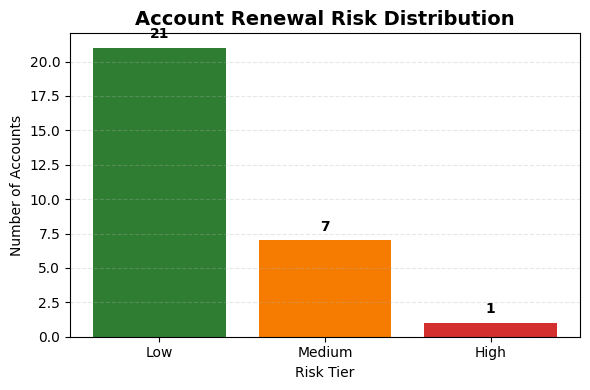

In [122]:
# --- Cell 12: Visual Risk Distribution ---
import matplotlib.pyplot as plt

tier_counts = df['risk_tier'].value_counts()
colors = {'High': '#d32f2f', 'Medium': '#f57c00', 'Low': '#2e7d32'}

plt.figure(figsize=(6, 4))
bars = plt.bar(tier_counts.index, tier_counts.values, color=[colors[t] for t in tier_counts.index])
plt.title('Account Renewal Risk Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Accounts')
plt.xlabel('Risk Tier')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add numbers on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [123]:
# --- Cell 13: CSM Action Playbook (Prioritized) ---

# Get the top 10 accounts (instead of just 5 for a broader view)
playbook_df = df[df['risk_tier'].isin(['High', 'Medium'])].sort_values('risk_score', ascending=False).head(10)

# Create a custom action summary if the LLM didn't provide one, or use the csm_action field
print("\n" + "="*80)
print("🚨 CSM ACTION PLAYBOOK (Top 10 At-Risk)")
print("="*80 + "\n")

for idx, row in playbook_df.iterrows():
    # Extract the most critical signal
    signal_text = ', '.join(row['csm_signals']) if isinstance(row['csm_signals'], list) else str(row['csm_signals'])
    if not signal_text:
        signal_text = "Usage decline / NPS drop"

    print(f"📌 {row['account_name']} (ARR: ${row['arr']:,.0f})")
    print(f"   • Risk: {row['risk_tier']} ({row['risk_score']:.0f}/100)")
    print(f"   • Key Signals: {signal_text}")
    print(f"   • Recommended Action: {row['csm_action'] if row['csm_action'] != 'No notes available.' else 'Prioritize touchpoint to understand churn risk.'}")
    print(f"   • Renewal Date: {row['contract_end_date'].date()}")
    print("   " + "-"*70)


🚨 CSM ACTION PLAYBOOK (Top 10 At-Risk)

📌 Stargazer Telescopes (ARR: $49,000)
   • Risk: High (71/100)
   • Key Signals: Usage decline / NPS drop
   • Recommended Action: Prioritize touchpoint to understand churn risk.
   • Renewal Date: 2026-10-20
   ----------------------------------------------------------------------
📌 Sunstone Energy (ARR: $253,000)
   • Risk: Medium (61/100)
   • Key Signals: Usage decline / NPS drop
   • Recommended Action: Prioritize touchpoint to understand churn risk.
   • Renewal Date: 2026-10-22
   ----------------------------------------------------------------------
📌 Oakridge Retail (ARR: $31,000)
   • Risk: Medium (60/100)
   • Key Signals: support issues, missing feature
   • Recommended Action: Monitor account.
   • Renewal Date: 2026-10-25
   ----------------------------------------------------------------------
📌 Magenta Health (ARR: $22,000)
   • Risk: Medium (58/100)
   • Key Signals: Usage decline / NPS drop
   • Recommended Action: Prioritize t

In [124]:
# --- Cell 14: Non-Obvious Insight Alert (Executive Summary) ---

# Recalculate hidden risk (accounts on v3 SDK, but currently Low risk)
hidden_risk = df[(df['on_v3'] == True) & (df['risk_tier'] == 'Low')]

print("\n" + "="*80)
print("💡 EXECUTIVE ALERT: NON-OBVIOUS RENEWAL RISK")
print("="*80 + "\n")
print("📢 The rule-based model classifies these accounts as 'Low Risk', but they are on SDK v3.x,")
print(f"which will STOP receiving security patches on April 30, 2026 (in { (pd.Timestamp('2026-04-30') - pd.Timestamp('2026-07-31')).days } days).")
print("\n🚨 These accounts are ticking time bombs for the REST API deprecation:\n")

if len(hidden_risk) > 0:
    for _, row in hidden_risk.iterrows():
        print(f"   🔴 {row['account_name']} (ID: {row['account_id']}) - Current SDK: {row['sdk_version']}")
        print(f"      └── Action: Escalate to Sales Engineer for immediate migration planning.")
else:
    print("   ✅ No 'hidden' v3 accounts found in the Low-risk tier. Good vigilance!")

print("\n" + "="*80)


💡 EXECUTIVE ALERT: NON-OBVIOUS RENEWAL RISK

📢 The rule-based model classifies these accounts as 'Low Risk', but they are on SDK v3.x,
which will STOP receiving security patches on April 30, 2026 (in -92 days).

🚨 These accounts are ticking time bombs for the REST API deprecation:

   ✅ No 'hidden' v3 accounts found in the Low-risk tier. Good vigilance!



In [125]:
# In your final display, modify the columns to show:
display(explain_df[['account_name', 'arr', 'contract_end_date', 'risk_tier',
                    'risk_score', 'csm_sentiment', 'explanation']].style.format({'arr': '${:,.0f}'}))

,account_name,arr,contract_end_date,risk_tier,risk_score,csm_sentiment,explanation
26,Stargazer Telescopes,"$49,000",2026-10-20 00:00:00,High,71.083860,Neutral,Stargazer Telescopes is at High risk due to 3 support tickets; 1 open tickets. Prioritize resolving open tickets.
28,Sunstone Energy,"$253,000",2026-10-22 00:00:00,Medium,60.612887,Neutral,Sunstone Energy is at Medium risk due to 3 support tickets; 1 open tickets; low NPS (2.0). Prioritize resolving open tickets.
23,Oakridge Retail,"$31,000",2026-10-25 00:00:00,Medium,60.378280,Neutral,"Oakridge Retail is at Medium risk due to 3 support tickets; 1 open tickets; support issues, missing feature. Prioritize resolving open tickets."
9,Magenta Health,"$22,000",2026-08-22 00:00:00,Medium,58.046866,Neutral,Magenta Health is at Medium risk due to moderate NPS (6.0). Schedule a proactive touchpoint before renewal.
0,Obsidian Data,"$68,000",2026-07-31 00:00:00,Medium,56.808933,Negative,"Obsidian Data is at Medium risk due to 3 support tickets; support issues, usage decline. Schedule a proactive touchpoint before renewal."
